#(15 pts) Consider the one dimensional linear partial differential equation:
$$\frac{\partial\psi}{\partial t}=-u\frac{\partial\psi}{\partial x}$$
where $u$ is a constant velocity and $\psi(x,t)$ is the analytical solution of the problem.

##(a) (1 pts) Discretize the equation in [1] using a second order scheme for the time and space derivatives and write the explicit solving algorithm.


**Answer:**

- Linear Advection Equation
$$\frac{\partial\psi}{\partial t}=-u\frac{\partial\psi}{\partial x}$$
- Analytical Solution
$$\psi(x,t)=F(x-ut)$$
- Leapfrog Scheme: CTCS: Centered in Time, Centered in Space
$$\frac{\psi^{n+1}_j-\psi^{n-1}_j}{2\Delta t}=-u\frac{\psi^n_{j+1}-\psi^n_{j-1}}{2\Delta x}$$

The explicit solving algorithm is then:
$$\psi^{n+1}_j=\psi^{n-1}_j-c(\psi^n_{j+1}-\psi^n_{j-1})$$

Wherein:
$$c=u\frac{\Delta t}{\Delta x}$$

This scheme is conditionally stable for solution with CFL condition:
$$|c|=|u|\frac{\Delta t}{\Delta x}\leq1$$
However, for the first time step, we must use FTFS when $u<0$ and FTBS when $u>0$. These are given as follows:

- FTFS: Forward in Time, Forward in Space
$$\frac{\psi^{n+1}_j-\psi^n_j}{\Delta t}+u\frac{\psi^n_{j+1}-\psi^n_j}{\Delta x}=0$$
$$\psi^{n+1}_j=(1+c)\psi^n_j-c\psi^n_{j+1}$$

- FTBS: Forward in Time, Backwards in Space
$$\frac{\psi^{n+1}_j-\psi^n_j}{\Delta t}+u\frac{\psi^n_j-\psi^n_{j-1}}{\Delta x}=0$$
$$\psi^{n+1}_j=(1-c)\psi^n_j+c\psi^n_{j-1}$$

##(b) (2 pts) Why are we interested in a stable numerical solution scheme and what are the implications in using a conditionally stable scheme?

**Answer:**

We are interested in a stable numerical solution scheme since we want the numerical solution to ideally converge into the analytical solution. Numerical solutions will always have a degree of error, which can be a problem if this error acccumulates at every iteration, preventing convergence. For a linear differential method, stability is necessary and sufficient for the convergence (Lax Equivalence Theorem).

For the CTCS, which is conditionally stable for a solution with CFL condition of $|c|=|u|\frac{\Delta t}{\Delta x}\leq1$, we have to strictly follow this condition. Otherwise, the numerical scheme will blow up values, and we will not reach an accurate representation of the analytical solution we are trying to represent.


##(c) (2 pts) Outline the methodology with which you would estimate the stability of the numerical solution scheme, without doing the calculation.

**Answer:**

The von Neumann method of stability analysis is the usual way of examining the accuracy and stability of linear partial differential equations.

To compute the stability of the numerical solution scheme, we must substitute $\psi^n_j\approx\psi(x_j,t^n)$ with $A^ne^{ikj\Delta x}$ in our numerical expression for $\psi^{n+1}_j$ to obtain an equation for the amplification factor $A$.

From this equation, we find the conditions that satisfy $|A|\le1$. This is the von Neumann requirement for the numerical scheme to be stable. Although this is necessary for the convergence of both linear and nonlinear equations, it is only sufficient for linear cases, and is insufficient for nonlinear cases.

##(d) (6 pts) Write a program implementing a solution algorithm defined in [1a]
in the periodic domain $x\in[0,750]$ using a spatial resolution of $\Delta x=0.15m$ and a constant advection velocity of $u=0.17m/s$ using the following initial conditions:
$$\psi(x,0)=\begin{bmatrix}
0.0 && \text{for } x<65\\
5.0 && \text{for }65\le x<85\\
10.0 && \text{for }85\le x<105\\
0.0 && \text{for } x>105
\end{bmatrix}$$

Integrate forward in time up to $t=1500s$ and plot the results every $300s$. Choose a $\Delta t$ to respect the CFL.

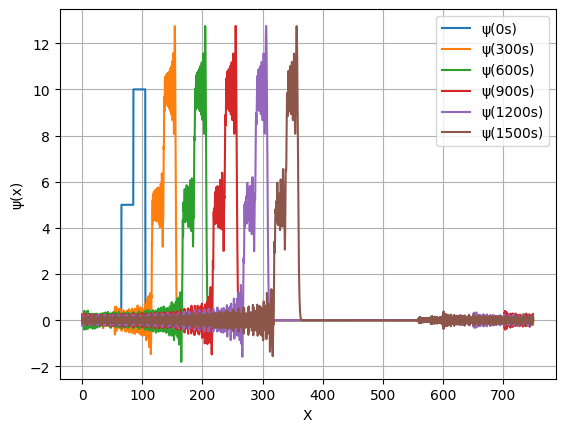

In [ ]:
#CTCS
import numpy as np
from matplotlib import pyplot as plt

def phi0(x): #phi(x,0)
    if (65<=x<85):
        return 5.0
    elif (85<=x<105):
        return 10.0
    else:
        return 0.0

def ftfs(phi_now):
    return (1+c)*phi_now-c*np.roll(phi_now,-1)

def ftbs(phi_now):
    return (1-c)*phi_now+c*np.roll(phi_now,1)

def ctcs(phi_old,phi_now):
    return phi_old-c*(np.roll(phi_now,-1)-np.roll(phi_now,1))

c=0.1
dx=0.15
u=0.17

dt=c*dx/u
t=0
t1=1500

x0=0
x1=750

x=np.arange(x0,x1,dx) #1D array of x-values between x0 and x1 with step nx
phi_old=[phi0(a) for a in x] #apply phi0 function to all x in array to fill phi array
phi_old=np.array(phi_old)
phi_now=phi_old.copy() #same dimensions
d=phi_old.copy() #same dimensions

#stability condition
#using ftbs or ftfs for phi_now
if (u>0):
    phi_now=ftbs(phi_old) #ftbs is stable if u>0
else:
    phi_now=ftfs(phi_old) #ftfs is stable if u<0

plt.plot(x, phi_now, label='ψ('+str(round(t0))+'s)')

t=t+dt

while(t<=t1+1):
    phi_new=ctcs(phi_old,phi_now) #using ctcs for everything else
    phi_old=phi_now
    phi_now=phi_new
    if (t==0) or (round(t,2)%300.==0):
        plt.plot(x,phi_now, label='ψ('+str(round(t))+'s)')
    t=t+dt

plt.xlabel('X')
plt.ylabel('ψ(x)')
plt.legend()
plt.grid()
plt.show()

##(e) (2 pts) Apply a time filter to the second order scheme in [1a]. What numerical problem is mitigated in doing it?

**Answer:**

The general form of the numerical solution has a physical mode proportional to the exact solution, and a computational mode that is an artifact of the numerical method. This computational mode does not correspond to any solution of the original PDE.

This computational mode creates large oscillations in value and hinders convergence into the true solution, as seen in [1d]. Filters like the Robert-Asselin-William filter serve to decrease the amplitude of the computational mode, so that the scheme will better converge, as seen in [1e].

- Robert-Asselin-William (RAW) Filter

Filter displacement:
$$d=\alpha(\psi^{n-1}-2\psi^n+\psi^{n+1})$$

Applying the filter in each update:
$$\hat{\psi}^n=\psi^n+\beta d$$
$$\hat{\psi}^{n+1}=\psi^{n+1}+(1-\beta)d$$
$$\psi^{n-1}=\hat{\psi}^n$$
$$\psi^n=\psi^{n+1}$$

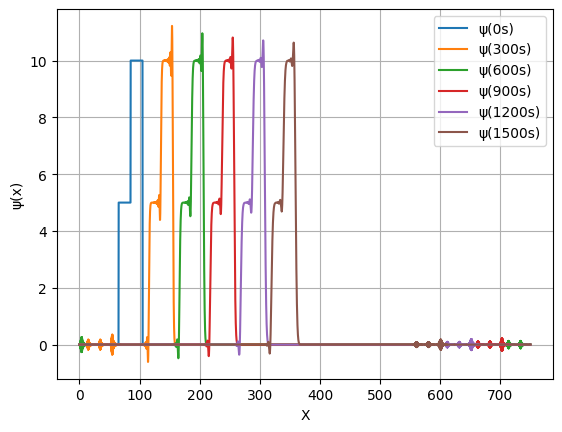

In [ ]:
#CTCS + RAW filter
import numpy as np
from matplotlib import pyplot as plt

def phi0(x): #phi(x,0)
    if (65<=x<85):
        return 5.0
    elif (85<=x<105):
        return 10.0
    else:
        return 0.0

def ftfs(phi_now):
    return (1+c)*phi_now-c*np.roll(phi_now,-1)

def ftbs(phi_now):
    return (1-c)*phi_now+c*np.roll(phi_now,1)

def ctcs(phi_old,phi_now):
    return phi_old-c*(np.roll(phi_now,-1)-np.roll(phi_now,1))

c=0.1
dx=0.15
u=0.17

dt=c*dx/u
t=0
t1=1500

x0=0
x1=750

#RAW filter
alpha=0.5
beta=0.6

x=np.arange(x0,x1,dx) #1D array of x-values between x0 and x1 with step nx
phi_old=[phi0(a) for a in x] #apply phi0 function to all x in array to fill phi array
phi_old=np.array(phi_old)
phi_now=phi_old.copy() #same dimensions
d=phi_old.copy() #same dimensions

#stability condition
#using ftbs or ftfs for phi_now
if (u>0):
    phi_now=ftbs(phi_old) #ftbs is stable if u>0
else:
    phi_now=ftfs(phi_old) #ftfs is stable if u<0

t=t+dt

plt.plot(x, phi_now, label='ψ('+str(round(t0))+'s)')

while(t<=t1+1):
    phi_new=ctcs(phi_old,phi_now) #using ctcs for everything else
    d=alpha*(phi_old+phi_new-2.0*phi_now) #RAW filter displacement
    phi_old=phi_now+beta*d #applying filtering in updating
    phi_now=phi_new+(1-beta)*d #applying filtering in updating
    if (t==0) or (round(t,2)%300.==0):
        plt.plot(x,phi_now, label='ψ('+str(round(t))+'s)')
    t=t+dt

plt.xlabel('X')
plt.ylabel('ψ(x)')
plt.legend()
plt.grid()
plt.show()

##(f) (2 pts) Add a diffusion term to the second order scheme in [1a]. Why this is important for solving non-linear problems?

**Answer:**

Nonlinearity can cause numerical problems when it comes to truncation and stability. It generates large gradients, such that the solution may explode into a singularity within a finite amount of time. The simplest way to address these numerical problems is to first use a linear formulation, and then include diffusion to prevent the formation of sharp gradients.

- Advection-Diffusion Problem
$$\frac{\partial\psi}{\partial t}+u\frac{\partial\psi}{\partial x}=K\frac{\partial^2\psi}{\partial x}$$

> Note that leapfrog (CTCS) is conditionally stable for advection (as long as $|c|=|u|\frac{\Delta t}{\Delta x}\leq1$).

> Also note that forward approximation is conditionally stable for diffusion (as long as $\Delta t\le\frac{\Delta x^2}{2K}$).

- Thus, the discretization becomes:
$$\frac{\psi^{n+1}_j-\psi^{n-1}_j}{2\Delta t}+u\frac{\psi^n_{j+1}-\psi^n_{j-1}}{2\Delta x}=K\biggr(\frac{\psi^{n-1}_{j+1}-2\psi^{n-1}_j+\psi^{n-1}_{j-1}}{\Delta x^2}\biggr)$$

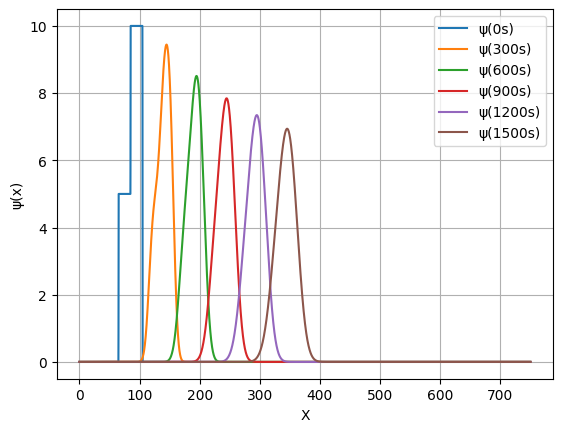

In [ ]:
#Advection-Diffusion
import numpy as np
from matplotlib import pyplot as plt

def phi0(x): #phi(x,0)
    if (65<=x<85):
        return 5.0
    elif (85<=x<105):
        return 10.0
    else:
        return 0.0

def ftcs_diff(p_now): #forward in time, centered in space + diffusion
    return p_now-0.5*c*(np.roll(p_now,-1)-np.roll(p_now,1))+dc*(np.roll(p_now,-1)-2.0*p_now+np.roll(p_now,1))

def ctcs_diff(p_old,p_now): #leapfrog, centered in time, centered in space + diffusion
    return p_old-c*(np.roll(p_now,-1)-np.roll(p_now,1))+2.0*dc*(np.roll(p_old,-1)-2.0*p_old+np.roll(p_old,1))

K=0.054

c=0.1
dx=0.15
u=0.17

dt=c*dx/u
t0=0
t1=1500

x0=0
x1=750

dc=K*dt/(dx**2) #alpha

x=np.arange(x0,x1+dx,dx)
p_now=[phi0(a) for a in x]
p_now=np.array(p_now)
p_old=p_now.copy()
p_new=p_now.copy()

p_now=ftcs_diff(p_old) #only for initial time field
plt.plot(x, p_now, label='ψ('+str(round(t0))+'s)')

t=t0+dt

while(t<=t1):
    if (round(t,1)%300.==0 and round(t,1)!=round(t-dt,1)):
        plt.plot(x, p_now, label='ψ('+str(round(t))+'s)')
    p_new=ctcs_diff(p_old,p_now) #ctcs for rest of field
    p_old=p_now
    p_now=p_new
    t=t+dt

plt.xlabel('X')
plt.ylabel('ψ(x)')
plt.legend()
plt.grid(visible=True)
plt.show()